# EDA Completo — PetFinder Adoption Prediction

**Dataset:** PetFinder Malaysia (Kaggle)  
**Objetivo:** Análisis exploratorio exhaustivo del dataset de adopción de mascotas para entender los factores que influyen en la velocidad de adopción (`AdoptionSpeed`).

---

In [2]:
# ══════════════════════════════════════════════════════════════════════
# BLOQUE 0 — Instalación de dependencias
# CAMBIO: bloque nuevo para instalar las librerías necesarias
# ══════════════════════════════════════════════════════════════════════
!pip install scikit-learn category_encoders --quiet

In [4]:
# ══════════════════════════════════════════════════════════════════════
# BLOQUE 1 — Setup
# CAMBIO: se agregaron imports de matplotlib y seaborn que faltaban
# ══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score
import category_encoders as ce
import warnings
warnings.filterwarnings('ignore')

# Estilo global de gráficos — sin cambios
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Paleta consistente para AdoptionSpeed — sin cambios
SPEED_COLORS  = {0: '#2ecc71', 1: '#27ae60', 2: '#f39c12', 3: '#e67e22', 4: '#e74c3c'}
SPEED_LABELS  = {0: '0-Mismo día', 1: '1-1ª semana', 2: '2-1er mes', 3: '3-2-3 meses', 4: '4-Sin adopción'}
SPEED_PALETTE = [SPEED_COLORS[i] for i in sorted(SPEED_COLORS)]


In [5]:

# ══════════════════════════════════════════════════════════════════════
# BLOQUE 2 — Carga de datos — sin cambios
# ══════════════════════════════════════════════════════════════════════
BASE_PATH    = '../input/petfinder-adoption-prediction'
train        = pd.read_csv(f'{BASE_PATH}/train/train.csv')
breed_labels = pd.read_csv(f'{BASE_PATH}/breed_labels.csv')
color_labels = pd.read_csv(f'{BASE_PATH}/color_labels.csv')
state_labels = pd.read_csv(f'{BASE_PATH}/state_labels.csv')


In [6]:


# ══════════════════════════════════════════════════════════════════════
# BLOQUE 3 — Features derivadas
# CAMBIO: Tiene_nombre pasa de True/False a 0/1
# ══════════════════════════════════════════════════════════════════════
# CAMBIO: 0/1 en lugar de True/False para evitar warnings en sklearn
train['Tiene_nombre'] = train['Name'].apply(
    lambda x: 0 if (pd.isna(x) or str(x).strip().lower() in ['no name', 'no name yet']) else 1
)

train['Desc_len_words'] = train['Description'].fillna('').apply(lambda x: len(str(x).split()))
train['PhotoAmt']       = train['PhotoAmt'].astype(int)

train['health_score'] = (
    (train['Vaccinated'] == 1).astype(int) +
    (train['Dewormed']   == 1).astype(int) +
    (train['Sterilized'] == 1).astype(int) +
    (train['Health']     == 1).astype(int)
)


In [7]:

# ══════════════════════════════════════════════════════════════════════
# BLOQUE 4 — Capping de outliers — sin cambios
# ══════════════════════════════════════════════════════════════════════
train['Age'] = train['Age'].clip(upper=60)
train['Fee'] = train['Fee'].clip(upper=500)

In [19]:
FEATURES = [
    'Type', 'Age', 'Gender', 'Breed1', 'Breed2',
    'Color1', 'Color2', 'MaturitySize', 'FurLength',
    'Vaccinated', 'Dewormed', 'Sterilized', 'Health',
    'Quantity', 'Fee', 'VideoAmt', 'PhotoAmt',
    'Tiene_nombre', 'Desc_len_words', 'health_score',
    'State',      # ← State lo dejamos, tiene pocos valores únicos
    # 'RescuerID_enc' ← ELIMINADO
]

for col in ['sent_score', 'sent_magnitude']:
    if col in train.columns and train[col].notna().sum() > 0:
        train[col] = train[col].fillna(0)
        FEATURES.append(col)
        print(f"✓ {col} incluido")
    else:
        print(f"✗ {col} no disponible, se omite")

✗ sent_score no disponible, se omite
✗ sent_magnitude no disponible, se omite


In [20]:


# ══════════════════════════════════════════════════════════════════════
# BLOQUE 7 — Preparar X e y — sin cambios
# ══════════════════════════════════════════════════════════════════════
X = train[FEATURES].copy()
y = train['AdoptionSpeed'].copy()

print(f"\nShape de X: {X.shape}")
print(f"Distribución del target:\n{y.value_counts().sort_index()}")


Shape de X: (14993, 21)
Distribución del target:
AdoptionSpeed
0     410
1    3090
2    4037
3    3259
4    4197
Name: count, dtype: int64


In [22]:
# ══════════════════════════════════════════════════════════════════════
# BLOQUE 8 — Modelo — sin cambios
# ══════════════════════════════════════════════════════════════════════
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',  # compensa el desbalance de clases del EDA
    random_state=42,
    n_jobs=-1
)


In [23]:



# ══════════════════════════════════════════════════════════════════════
# BLOQUE 9 — Validación con StratifiedKFold — sin cambios
# ══════════════════════════════════════════════════════════════════════
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
qwk_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    rf.fit(X_train, y_train)
    preds = rf.predict(X_val)

    qwk = cohen_kappa_score(y_val, preds, weights='quadratic')
    qwk_scores.append(qwk)
    print(f"Fold {fold+1} — QWK: {qwk:.4f}")

print(f"\n✅ QWK promedio: {np.mean(qwk_scores):.4f} ± {np.std(qwk_scores):.4f}")

Fold 1 — QWK: 0.3382
Fold 2 — QWK: 0.3675
Fold 3 — QWK: 0.3771
Fold 4 — QWK: 0.3282
Fold 5 — QWK: 0.3829

✅ QWK promedio: 0.3588 ± 0.0217


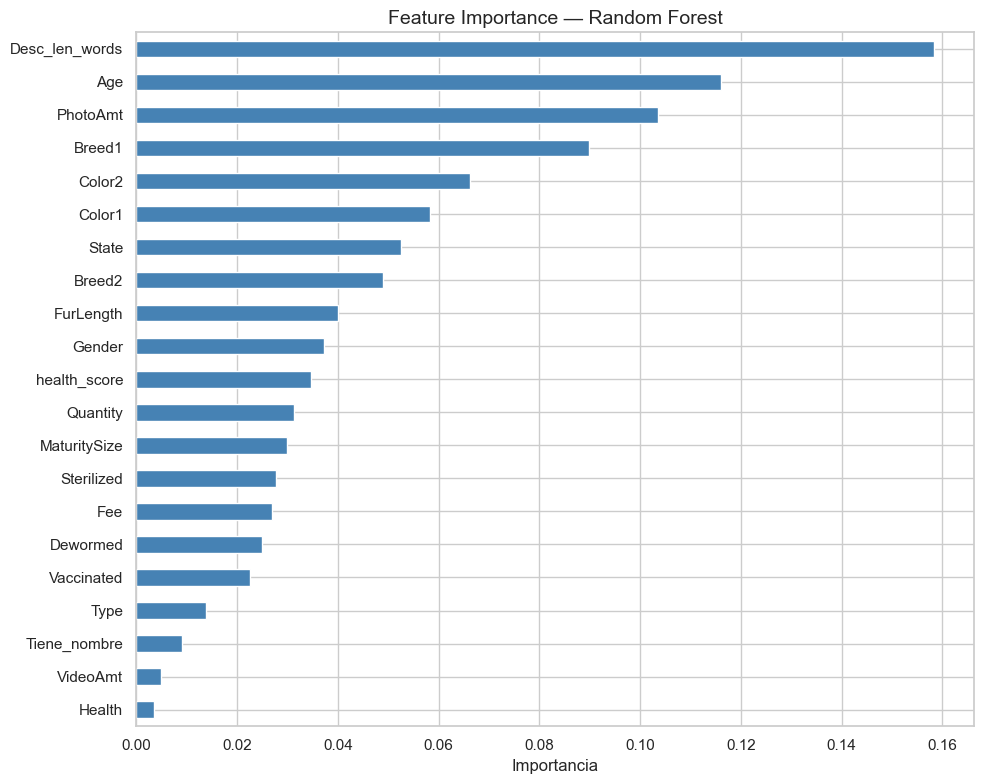

In [24]:

# BLOQUE 10 — Feature importance — sin cambios
# ══════════════════════════════════════════════════════════════════════
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()